# Chapter 11. Time Series
- Many time series are **fixed frequency**, which is to say that data points occur at regular intervals according to some rule.
> - **Timestamps:** Specific instants in time.
> - **Fixed periods:** Such as the whole month of January 2017, or the whole year 2020.
> - **Intervals of time:** Indicated by start and end timestamp. Periods can be thought of as special cases of intervals.
> - **Experiment or elapsed time:** Each timestamp is a measure of time relative to a particular start time.
- Many of the techniques can be applied to experimental time series where the **index may be an integer or floating-point number** indicating elapsed time from the start of the experiment.
- Pandas also **supports indexes based on timedeltas**, which can be a useful way of representing experiment or elaspsed time.

In [1]:
import numpy as np
import pandas as pd

In [2]:
from datetime import datetime

In [3]:
from datetime import timedelta

## 11.3 Date Ranges, Frequencies, and Shifting
- Pandas has a full suite of **standard time series frequencies** and tools for **resampling, inferring frequencies, and generating fixed-frequency date ranges**.

### Generating Date Ranges
- ***pandas.date_range*** is responsible for generating a **DatetimeIndex with an indicated length** according to particular frequency:

In [4]:
index = pd.date_range('2012-04-01', '2012-06-01')
index

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20',
               '2012-04-21', '2012-04-22', '2012-04-23', '2012-04-24',
               '2012-04-25', '2012-04-26', '2012-04-27', '2012-04-28',
               '2012-04-29', '2012-04-30', '2012-05-01', '2012-05-02',
               '2012-05-03', '2012-05-04', '2012-05-05', '2012-05-06',
               '2012-05-07', '2012-05-08', '2012-05-09', '2012-05-10',
               '2012-05-11', '2012-05-12', '2012-05-13', '2012-05-14',
               '2012-05-15', '2012-05-16', '2012-05-17', '2012-05-18',
               '2012-05-19', '2012-05-20', '2012-05-21', '2012-05-22',
               '2012-05-23', '2012-05-24', '2012-05-25', '2012-05-26',
      

- By default, *pandas.date_range* generates daily timestamps.

In [6]:
pd.date_range(start='2012-04-01', periods=20)
# = pd.date_range(end='2012-04-19', periods=20)

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20'],
              dtype='datetime64[ns]', freq='D')

In [7]:
pd.date_range('2000-01-01', '2000-12-01', freq='BM')

DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BM')

> 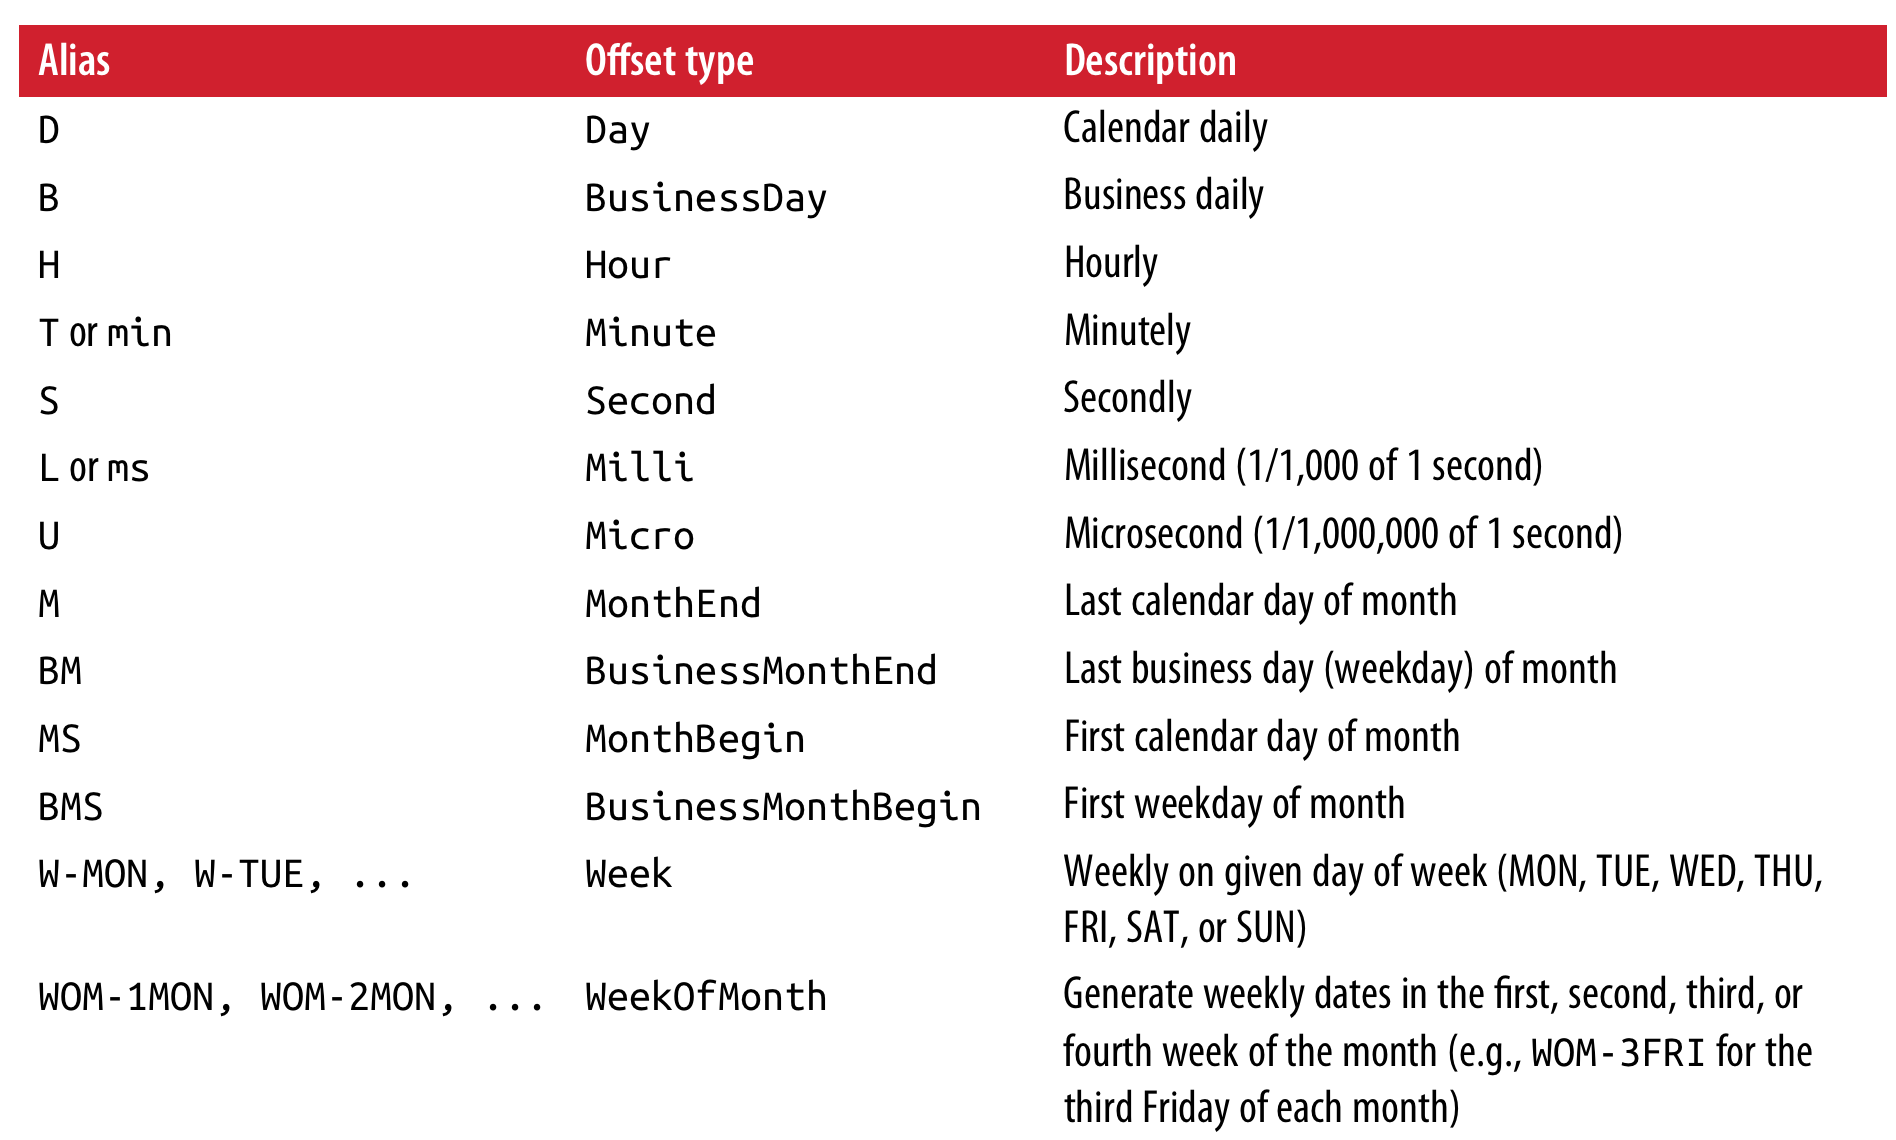

- 그 밖의 frequency에 대해서는 교재 참고!

> - pandas.date_range by default preserves the time(if any) of the start or end timestamp:

In [8]:
pd.date_range('2012-05-02 12:56:31', periods=5)

DatetimeIndex(['2012-05-02 12:56:31', '2012-05-03 12:56:31',
               '2012-05-04 12:56:31', '2012-05-05 12:56:31',
               '2012-05-06 12:56:31'],
              dtype='datetime64[ns]', freq='D')

> - To generate a set of timestamps ***normalized* to midnight as a convention**, there is a ***normalize*** option:

In [9]:
pd.date_range('2012-05-02 12:56:31', periods=5, normalize=True)

DatetimeIndex(['2012-05-02', '2012-05-03', '2012-05-04', '2012-05-05',
               '2012-05-06'],
              dtype='datetime64[ns]', freq='D')

### Frequencies and Date Offsets
- Frequencies in pandas are composed of a **base frequency and a multiplier**.
- For each base frequency, there is an object referred to as a ***date offset***:

In [4]:
from pandas.tseries.offsets import Hour, Minute

In [5]:
hour = Hour()

> - You can define a multiple of an offset by passing an integer:

In [7]:
four_hours = Hour(4)

In [8]:
four_hours

<4 * Hours>

> - In most applications, you would never to explicitly create one of these objects; **instead you'd use a string alias like "H" or "4H"**.

In [9]:
pd.date_range('2000-01-01', '2000-01-03 23:59', freq='4H')

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 04:00:00',
               '2000-01-01 08:00:00', '2000-01-01 12:00:00',
               '2000-01-01 16:00:00', '2000-01-01 20:00:00',
               '2000-01-02 00:00:00', '2000-01-02 04:00:00',
               '2000-01-02 08:00:00', '2000-01-02 12:00:00',
               '2000-01-02 16:00:00', '2000-01-02 20:00:00',
               '2000-01-03 00:00:00', '2000-01-03 04:00:00',
               '2000-01-03 08:00:00', '2000-01-03 12:00:00',
               '2000-01-03 16:00:00', '2000-01-03 20:00:00'],
              dtype='datetime64[ns]', freq='4H')

> - **Many offset can be combined by addition**:
> - Similarly, you can pass frequency strings, like "1h30min"
> - Users can define their **own custom frequency classes** to provide date logic not available in pandas.

In [10]:
pd.date_range('2000-01-01', periods=10, freq="1h30min")

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 01:30:00',
               '2000-01-01 03:00:00', '2000-01-01 04:30:00',
               '2000-01-01 06:00:00', '2000-01-01 07:30:00',
               '2000-01-01 09:00:00', '2000-01-01 10:30:00',
               '2000-01-01 12:00:00', '2000-01-01 13:30:00'],
              dtype='datetime64[ns]', freq='90T')

> - One useful frequency class is **"week of month,"** starting with ***WOM***. This enables you to get dates like the third Friday of each month:

In [10]:
monthly_dates = pd.date_range("2012-01-01", "2012-09-01", freq='WOM-3FRI')
list(monthly_dates)

[Timestamp('2012-01-20 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-02-17 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-03-16 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-04-20 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-05-18 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-06-15 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-07-20 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-08-17 00:00:00', freq='WOM-3FRI')]

### Shifting (Leading and Lagging) Data
- ***Shifting*** refers to **moving data backward and forward through time**.
- Both Series and DataFrame have a ***shift*** method for doing naive shifts forward or backward, **leaving the index unmodified**:

In [5]:
ts = pd.Series(np.random.standard_normal(4), 
               index=pd.date_range('2000-01-01', periods=4, freq='M'))

In [6]:
ts

2000-01-31    0.146756
2000-02-29   -2.592823
2000-03-31   -1.904570
2000-04-30   -0.460857
Freq: M, dtype: float64

In [7]:
ts.shift(2)

2000-01-31         NaN
2000-02-29         NaN
2000-03-31    0.146756
2000-04-30   -2.592823
Freq: M, dtype: float64

> - A common use of ***shift*** is computing consecutive percent changes in a time series or multiple time series as DataFrame columns.

In [8]:
ts/ts.shift(2)

2000-01-31          NaN
2000-02-29          NaN
2000-03-31   -12.977781
2000-04-30     0.177743
Freq: M, dtype: float64

> - **If the frequency is known**, it can be passed to *shift* to advance the timestamps **instead of simply the data**:

In [9]:
ts.shift(2, freq='M')

2000-03-31    0.146756
2000-04-30   -2.592823
2000-05-31   -1.904570
2000-06-30   -0.460857
Freq: M, dtype: float64

> - Other frequencies can be passed, too, giving you some flexibility in how to lead and lag data:

In [10]:
ts.shift(3, freq='D')

2000-02-03    0.146756
2000-03-03   -2.592823
2000-04-03   -1.904570
2000-05-03   -0.460857
dtype: float64

In [11]:
ts.shift(1, freq='90T')
# The "T" here stands for minutes

2000-01-31 01:30:00    0.146756
2000-02-29 01:30:00   -2.592823
2000-03-31 01:30:00   -1.904570
2000-04-30 01:30:00   -0.460857
dtype: float64

- Note that the ***freq* parameter here indicates the offset to apply to the timestamps, but it does not change the underlying frequency of the data**, if any.

### Shifting dates with offsets
- The pandas date offsets can also be used with *datetime* or *Timestamp* objects:

In [4]:
from pandas.tseries.offsets import Day, MonthEnd

In [5]:
now = datetime(2011,11,17)
now + 3*Day()

Timestamp('2011-11-20 00:00:00')

> - If you add an anchored offset like ***MonthEnd***, the **first increment will "roll forward" a date to the next date according to the frequency rule**:
> - Anchored offsets can explicity "roll" dates forward or backward by simply using their ***rollforward*** and ***rollback*** method, repectively:

In [6]:
now + MonthEnd()

Timestamp('2011-11-30 00:00:00')

In [7]:
now + MonthEnd(2)

Timestamp('2011-12-31 00:00:00')

In [8]:
offset = MonthEnd()
offset.rollforward(now)

Timestamp('2011-11-30 00:00:00')

In [9]:
offset.rollback(now)

Timestamp('2011-10-31 00:00:00')

> - A creative use of date offsets is to use these methods with ***groupby***:

In [11]:
ts = pd.Series(np.random.standard_normal(20),
               index=pd.date_range('2000-01-15', periods=20, freq='4D'))
ts

2000-01-15   -0.512482
2000-01-19   -0.483087
2000-01-23   -0.274530
2000-01-27    0.655866
2000-01-31    1.576231
2000-02-04   -0.409542
2000-02-08   -0.658545
2000-02-12   -0.844406
2000-02-16    2.685531
2000-02-20   -2.224031
2000-02-24    0.493680
2000-02-28    0.324692
2000-03-03   -0.232430
2000-03-07    0.366267
2000-03-11    0.673354
2000-03-15   -0.020302
2000-03-19    1.833233
2000-03-23   -0.665588
2000-03-27    0.814125
2000-03-31    0.666977
Freq: 4D, dtype: float64

In [13]:
ts.groupby(MonthEnd().rollforward).mean()
# = ts.resample('M').mean() , an easier and faster way

2000-01-31    0.192399
2000-02-29   -0.090374
2000-03-31    0.429454
dtype: float64

## 11.4 Time Zone Handling

In [5]:
import pytz

In [6]:
pytz.common_timezones[-5:]

['US/Eastern', 'US/Hawaii', 'US/Mountain', 'US/Pacific', 'UTC']

In [7]:
tz = pytz.timezone('America/New_York')
tz

<DstTzInfo 'America/New_York' LMT-1 day, 19:04:00 STD>

### Time Zone Localization and Conversion
- By default, time series in pandas are ***time zone naive***

In [8]:
dates = pd.date_range('2012-03-09 09:30', periods=6)

- Date range can be generated with a time zone set:
    - pd.date_range('2012-03-09 09:30, periods=6, tz='UTC')

In [9]:
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts

2012-03-09 09:30:00    1.993097
2012-03-10 09:30:00   -0.077321
2012-03-11 09:30:00    0.261948
2012-03-12 09:30:00   -0.165113
2012-03-13 09:30:00   -0.740690
2012-03-14 09:30:00   -2.074690
Freq: D, dtype: float64

In [10]:
print(ts.index.tz)

None


> - **Conversion from naive to localized**(reinterpreted as having been observed in a particular time zone) is hadled by the ***tz_localize*** method:

In [11]:
ts_utc = ts.tz_localize('UTC')
ts_utc

2012-03-09 09:30:00+00:00   -0.089318
2012-03-10 09:30:00+00:00   -1.098145
2012-03-11 09:30:00+00:00   -1.633800
2012-03-12 09:30:00+00:00    0.053868
2012-03-13 09:30:00+00:00   -0.139456
2012-03-14 09:30:00+00:00   -0.250665
Freq: D, dtype: float64

In [12]:
ts_utc.index

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

In [14]:
print(ts_utc.index.tz)

UTC


> - Once a time series has been localized to a particular time zone, it can be **converted to another time zone with *tz_convert***:

In [21]:
ts_utc.tz_convert('America/New_York')

2012-03-09 04:30:00-05:00   -0.089318
2012-03-10 04:30:00-05:00   -1.098145
2012-03-11 05:30:00-04:00   -1.633800
2012-03-12 05:30:00-04:00    0.053868
2012-03-13 05:30:00-04:00   -0.139456
2012-03-14 05:30:00-04:00   -0.250665
Freq: D, dtype: float64

> - ***tz_localize*** and ***tz_convert*** are also instance methods on **DatetimeIndex**:

In [27]:
ts.index.tz_localize('Asia/Shanghai')

DatetimeIndex(['2012-03-09 09:30:00+08:00', '2012-03-10 09:30:00+08:00',
               '2012-03-11 09:30:00+08:00', '2012-03-12 09:30:00+08:00',
               '2012-03-13 09:30:00+08:00', '2012-03-14 09:30:00+08:00'],
              dtype='datetime64[ns, Asia/Shanghai]', freq=None)